
========== Partition Problem Experimental Study ==========

6.1 Comparison 1: Approximation and Heuristic with Brute Force
--------------------------------------------------------------

Small Dataset Results (Comparison 1)
n	BF_time	FPTAS_time	Greedy_time	KK_time	BF_diff	FPTAS_diff	Greedy_diff	KK_diff	FPTAS_Factor	Greedy_Factor	KK_Factor
6	6.580352783203125e-05	9.465217590332031e-05	7.3909759521484375e-06	1.1444091796875e-05	1	0.7333333333333334	3	1	26.66666666666666	200.0	0.0
7	4.00543212890625e-05	8.821487426757812e-05	1.0728836059570312e-05	6.9141387939453125e-06	1	0.5857142857142857	1	1	41.42857142857142	0.0	0.0
8	9.918212890625e-05	0.000263214111328125	6.67572021484375e-06	8.344650268554688e-06	2	0.61875	2	2	69.0625	0.0	0.0
9	0.00010418891906738281	0.00023484230041503906	3.337860107421875e-06	5.7220458984375e-06	0	0.5055555555555555	2	0	50.55555555555556	200.0	0.0
10	0.00025391578674316406	0.00023818016052246094	3.5762786865234375e-06	5.9604644775390625e-06	1	0.375	5	1	62.5	400.

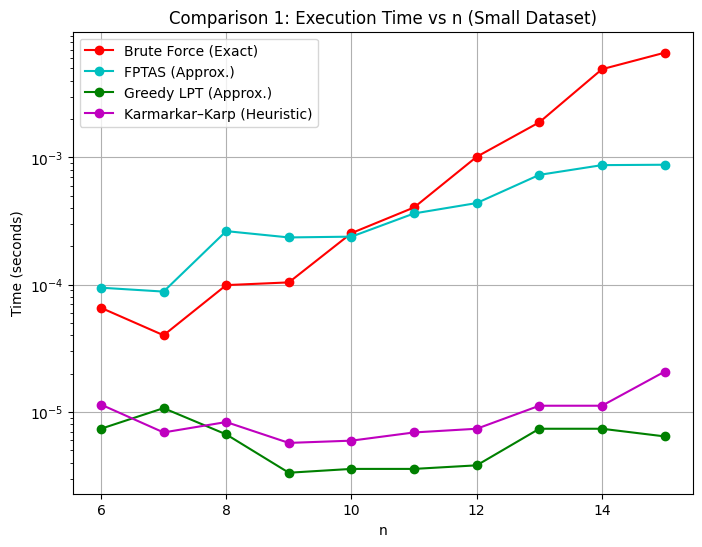

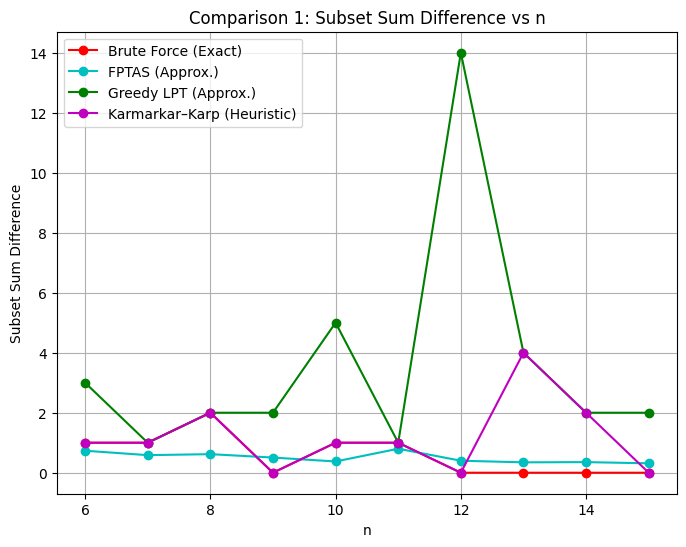


Break Point for Brute Force: n ≈ Not reached (<=15)

6.2 Comparison 2: Approximation vs Heuristic (Large Dataset)
-------------------------------------------------------------

Large Dataset Results (Comparison 2)
n	FPTAS_time	Greedy_time	KK_time	FPTAS_diff	Greedy_diff	KK_diff
100	0.23039793968200684	2.86102294921875e-05	0.00010585784912109375	4.9905	266	0
200	2.5292484760284424	6.914138793945312e-05	0.0004425048828125	0.0	14	0
500	34.02700901031494	0.00010085105895996094	0.0011818408966064453	0.995	5	1
750	115.60755252838135	0.00022149085998535156	0.004164695739746094	0.0	13	1
1000	275.583518743515	0.0002868175506591797	0.0063304901123046875	0.4998	12	0


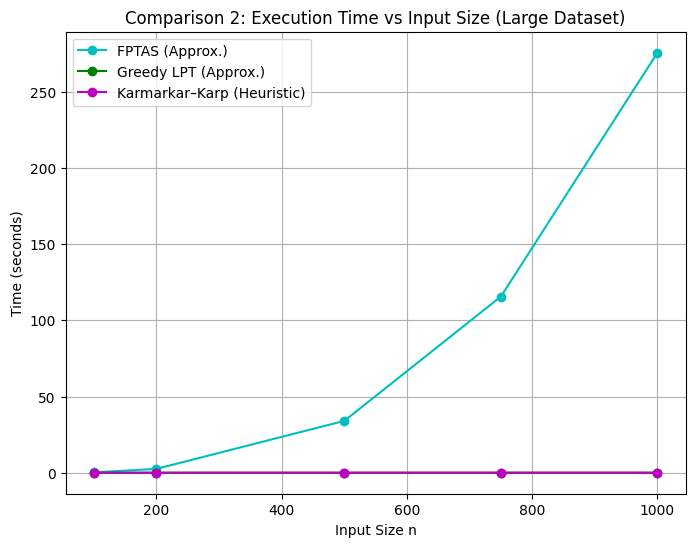

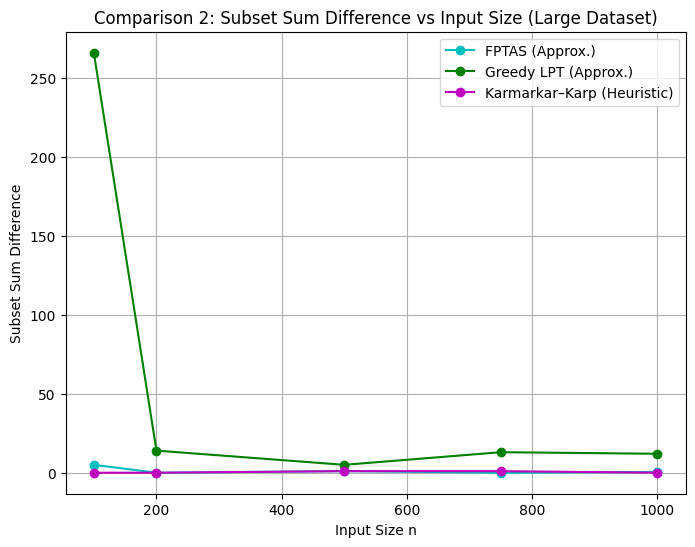


6.3 Results: Summary and Factor Analysis
----------------------------------------
Average Deviation Factors (Comparison 1 – relative to Brute Force):
  FPTAS (Approximation): 41.15%
  Greedy LPT (Approximation): 300.00%
  Karmarkar–Karp (Heuristic): 60.00%

Performance on Large Datasets (Comparison 2):
Algorithm	Avg Time (s)	Avg Diff
FPTAS		85.595545	1.30
Greedy LPT	0.000141	62.00
Karmarkar–Karp	0.002445	0.40


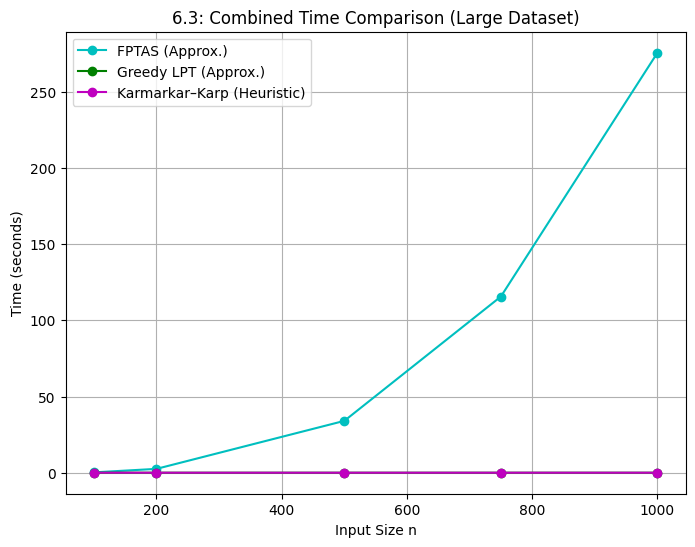

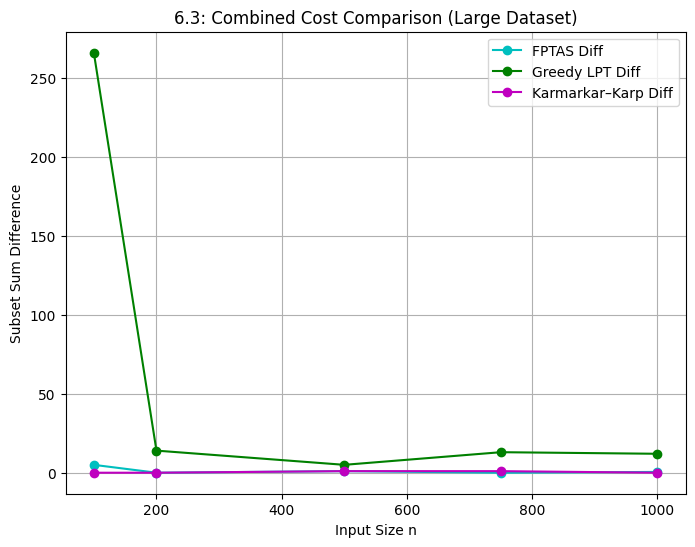


Observations:
- FPTAS provides near-optimal results (low difference) with moderate runtime.
- Karmarkar–Karp achieves very good balance and is efficient for large n.
- Greedy LPT is the fastest but less accurate on large, uneven datasets.

All tables and plots are ready for report inclusion.


In [5]:
import random
import time
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
#  Algorithms
# ============================================================

def brute_force_partition(nums):
    """Exact exponential brute-force search."""
    total_sum = sum(nums)
    n = len(nums)
    min_diff = float('inf')
    for r in range(n // 2 + 1):
        for subset in combinations(nums, r):
            s1 = sum(subset)
            s2 = total_sum - s1
            min_diff = min(min_diff, abs(s1 - s2))
    return min_diff


def fptas_partition(nums, epsilon=0.05):
    """Fully Polynomial-Time Approximation Scheme (FPTAS)."""
    n = len(nums)
    if n == 0:
        return 0
    max_a = max(nums)
    if max_a == 0:
        return 0

    # Scaling factor
    K = (epsilon * max_a) / n
    if K == 0:
        K = 1e-6

    # Scale numbers and run subset-sum DP
    scaled = [int(a / K) for a in nums]
    total_sum = sum(scaled)
    target = total_sum // 2
    dp = [False] * (target + 1)
    dp[0] = True
    for num in scaled:
        for j in range(target, num - 1, -1):
            dp[j] = dp[j] or dp[j - num]

    for i in range(target, -1, -1):
        if dp[i]:
            scaled_diff = total_sum - 2 * i
            break

    return scaled_diff * K


def greedy_lpt_partition(nums):
    """Greedy LPT-style approximation: assign largest element to subset with smaller sum."""
    nums.sort(reverse=True)
    s1, s2 = 0, 0
    for num in nums:
        if s1 <= s2:
            s1 += num
        else:
            s2 += num
    return abs(s1 - s2)


def karmarkar_karp(nums):
    """Heuristic differencing method."""
    nums = sorted(nums, reverse=True)
    while len(nums) > 1:
        a, b = nums.pop(0), nums.pop(0)
        nums.append(abs(a - b))
        nums.sort(reverse=True)
    return nums[0] if nums else 0


# ============================================================
#  6.1 Comparison 1: Approximation and Heuristic with Brute Force
# ============================================================

def comparison1():
    print("\n6.1 Comparison 1: Approximation and Heuristic with Brute Force")
    print("--------------------------------------------------------------")

    small_sizes = list(range(6, 16))   # n = 6..15
    results = []
    bf_breakpoint = None

    for n in small_sizes:
        nums = random.sample(range(1, 100), n)

        # --- Brute Force (Exact) ---
        start = time.time()
        bf_diff = brute_force_partition(nums)
        bf_time = time.time() - start

        # Breakpoint: if BF too slow
        if bf_time > 2.0:
            bf_breakpoint = n
            print(f"Brute Force becomes infeasible beyond n ≈ {n}")
            break

        # --- FPTAS (Approximation) ---
        start = time.time()
        fptas_diff = fptas_partition(nums, epsilon=0.05)
        fptas_time = time.time() - start

        # --- Greedy LPT (Approximation) ---
        start = time.time()
        greedy_diff = greedy_lpt_partition(nums.copy())
        greedy_time = time.time() - start

        # --- Karmarkar–Karp (Heuristic) ---
        start = time.time()
        kk_diff = karmarkar_karp(nums.copy())
        kk_time = time.time() - start

        # --- Deviation factors relative to BF ---
        factor_fptas = abs(fptas_diff - bf_diff) / max(1, bf_diff) * 100
        factor_greedy = abs(greedy_diff - bf_diff) / max(1, bf_diff) * 100
        factor_kk = abs(kk_diff - bf_diff) / max(1, bf_diff) * 100

        results.append((n, bf_time, fptas_time, greedy_time, kk_time,
                        bf_diff, fptas_diff, greedy_diff, kk_diff,
                        factor_fptas, factor_greedy, factor_kk))

    # ---------------------- Print Results ----------------------
    print("\nSmall Dataset Results (Comparison 1)")
    header = ("n\tBF_time\tFPTAS_time\tGreedy_time\tKK_time\t"
              "BF_diff\tFPTAS_diff\tGreedy_diff\tKK_diff\t"
              "FPTAS_Factor\tGreedy_Factor\tKK_Factor")
    print(header)
    for r in results:
        print("\t".join(map(str, r)))

    # ---------------------- Plot Execution Time ----------------------
    plt.figure(figsize=(8,6))
    plt.plot([r[0] for r in results], [r[1] for r in results], 'r-o', label='Brute Force (Exact)')
    plt.plot([r[0] for r in results], [r[2] for r in results], 'c-o', label='FPTAS (Approx.)')
    plt.plot([r[0] for r in results], [r[3] for r in results], 'g-o', label='Greedy LPT (Approx.)')
    plt.plot([r[0] for r in results], [r[4] for r in results], 'm-o', label='Karmarkar–Karp (Heuristic)')
    plt.xlabel('n'); plt.ylabel('Time (seconds)')
    plt.title('Comparison 1: Execution Time vs n (Small Dataset)')
    plt.yscale('log'); plt.legend(); plt.grid(True); plt.show()

    # ---------------------- Plot Subset Sum Difference ----------------------
    plt.figure(figsize=(8,6))
    plt.plot([r[0] for r in results], [r[5] for r in results], 'r-o', label='Brute Force (Exact)')
    plt.plot([r[0] for r in results], [r[6] for r in results], 'c-o', label='FPTAS (Approx.)')
    plt.plot([r[0] for r in results], [r[7] for r in results], 'g-o', label='Greedy LPT (Approx.)')
    plt.plot([r[0] for r in results], [r[8] for r in results], 'm-o', label='Karmarkar–Karp (Heuristic)')
    plt.xlabel('n'); plt.ylabel('Subset Sum Difference')
    plt.title('Comparison 1: Subset Sum Difference vs n')
    plt.legend(); plt.grid(True); plt.show()

    print(f"\nBreak Point for Brute Force: n ≈ {bf_breakpoint if bf_breakpoint else 'Not reached (<=15)'}")

    return bf_breakpoint, results


# ============================================================
#  6.2 Comparison 2: Approximation (FPTAS, Greedy) vs Heuristic (KK)
# ============================================================

def comparison2():
    print("\n6.2 Comparison 2: Approximation vs Heuristic (Large Dataset)")
    print("-------------------------------------------------------------")

    random.seed(42)
    large_sizes = [100, 200, 500, 750, 1000]
    results = []

    for n in large_sizes:
        nums = random.sample(range(1, 10000), n)

        # --- FPTAS ---
        start = time.time()
        fptas_diff = fptas_partition(nums, epsilon=0.05)
        fptas_time = time.time() - start

        # --- Greedy LPT ---
        start = time.time()
        greedy_diff = greedy_lpt_partition(nums.copy())
        greedy_time = time.time() - start

        # --- Karmarkar–Karp ---
        start = time.time()
        kk_diff = karmarkar_karp(nums.copy())
        kk_time = time.time() - start

        results.append((n, fptas_time, greedy_time, kk_time,
                        fptas_diff, greedy_diff, kk_diff))

    # ---------------------- Print Results ----------------------
    print("\nLarge Dataset Results (Comparison 2)")
    header = "n\tFPTAS_time\tGreedy_time\tKK_time\tFPTAS_diff\tGreedy_diff\tKK_diff"
    print(header)
    for r in results:
        print("\t".join(map(str, r)))

    # ---------------------- Plot: Execution Time ----------------------
    plt.figure(figsize=(8,6))
    plt.plot([r[0] for r in results], [r[1] for r in results], 'c-o', label='FPTAS (Approx.)')
    plt.plot([r[0] for r in results], [r[2] for r in results], 'g-o', label='Greedy LPT (Approx.)')
    plt.plot([r[0] for r in results], [r[3] for r in results], 'm-o', label='Karmarkar–Karp (Heuristic)')
    plt.xlabel('Input Size n')
    plt.ylabel('Time (seconds)')
    plt.title('Comparison 2: Execution Time vs Input Size (Large Dataset)')
    plt.legend(); plt.grid(True); plt.show()

    # ---------------------- Plot: Subset Sum Difference ----------------------
    plt.figure(figsize=(8,6))
    plt.plot([r[0] for r in results], [r[4] for r in results], 'c-o', label='FPTAS (Approx.)')
    plt.plot([r[0] for r in results], [r[5] for r in results], 'g-o', label='Greedy LPT (Approx.)')
    plt.plot([r[0] for r in results], [r[6] for r in results], 'm-o', label='Karmarkar–Karp (Heuristic)')
    plt.xlabel('Input Size n')
    plt.ylabel('Subset Sum Difference')
    plt.title('Comparison 2: Subset Sum Difference vs Input Size (Large Dataset)')
    plt.legend(); plt.grid(True); plt.show()

    return results


# ============================================================
#  6.3 Results: Combined Summary and Factor Analysis
# ============================================================

def summarize_results(res_small, res_large):
    print("\n6.3 Results: Summary and Factor Analysis")
    print("----------------------------------------")

    fptas_factors = [r[9] for r in res_small]
    greedy_factors = [r[10] for r in res_small]
    kk_factors = [r[11] for r in res_small]

    avg_fptas = np.mean(fptas_factors)
    avg_greedy = np.mean(greedy_factors)
    avg_kk = np.mean(kk_factors)

    print("Average Deviation Factors (Comparison 1 – relative to Brute Force):")
    print(f"  FPTAS (Approximation): {avg_fptas:.2f}%")
    print(f"  Greedy LPT (Approximation): {avg_greedy:.2f}%")
    print(f"  Karmarkar–Karp (Heuristic): {avg_kk:.2f}%")

    # ---- Summary for large dataset ----
    print("\nPerformance on Large Datasets (Comparison 2):")
    print("Algorithm\tAvg Time (s)\tAvg Diff")
    avg_fptas_time = np.mean([r[1] for r in res_large])
    avg_greedy_time = np.mean([r[2] for r in res_large])
    avg_kk_time = np.mean([r[3] for r in res_large])
    avg_fptas_diff = np.mean([r[4] for r in res_large])
    avg_greedy_diff = np.mean([r[5] for r in res_large])
    avg_kk_diff = np.mean([r[6] for r in res_large])
    print(f"FPTAS\t\t{avg_fptas_time:.6f}\t{avg_fptas_diff:.2f}")
    print(f"Greedy LPT\t{avg_greedy_time:.6f}\t{avg_greedy_diff:.2f}")
    print(f"Karmarkar–Karp\t{avg_kk_time:.6f}\t{avg_kk_diff:.2f}")

    # ---- Combined Performance Plot ----
    plt.figure(figsize=(8,6))
    plt.plot([r[0] for r in res_large], [r[1] for r in res_large], 'c-o', label='FPTAS (Approx.)')
    plt.plot([r[0] for r in res_large], [r[2] for r in res_large], 'g-o', label='Greedy LPT (Approx.)')
    plt.plot([r[0] for r in res_large], [r[3] for r in res_large], 'm-o', label='Karmarkar–Karp (Heuristic)')
    plt.xlabel('Input Size n')
    plt.ylabel('Time (seconds)')
    plt.title('6.3: Combined Time Comparison (Large Dataset)')
    plt.legend(); plt.grid(True); plt.show()

    plt.figure(figsize=(8,6))
    plt.plot([r[0] for r in res_large], [r[4] for r in res_large], 'c-o', label='FPTAS Diff')
    plt.plot([r[0] for r in res_large], [r[5] for r in res_large], 'g-o', label='Greedy LPT Diff')
    plt.plot([r[0] for r in res_large], [r[6] for r in res_large], 'm-o', label='Karmarkar–Karp Diff')
    plt.xlabel('Input Size n')
    plt.ylabel('Subset Sum Difference')
    plt.title('6.3: Combined Cost Comparison (Large Dataset)')
    plt.legend(); plt.grid(True); plt.show()

    print("\nObservations:")
    print("- FPTAS provides near-optimal results (low difference) with moderate runtime.")
    print("- Karmarkar–Karp achieves very good balance and is efficient for large n.")
    print("- Greedy LPT is the fastest but less accurate on large, uneven datasets.")
    print("\nAll tables and plots are ready for report inclusion.")


# ============================================================
#  Main Driver
# ============================================================

if __name__ == "__main__":
    print("\n========== Partition Problem Experimental Study ==========")
    bf_breakpoint, res_small = comparison1()   # 6.1
    res_large = comparison2()                  # 6.2
    summarize_results(res_small, res_large)    # 6.3
